# Objective

The goal is to detect cells in 3D microscopy images, associate detections across time and reconstruct cell lineages, including division events.

# Load and Inspect Data

## Inspect File Structure

In [1]:
from pathlib import Path

# INPUT_ROOT = Path("~/Desktop")
# COMPETITION_NAME = "biohub-cell-tracking-during-development"
DATA_ROOT = Path("/home/priyam-ambastha/Desktop/biohub-cell-tracking-during-development")

print("Data root exists:", DATA_ROOT.exists())
print("Data root:", DATA_ROOT)

if DATA_ROOT.exists():
    for path in sorted(DATA_ROOT.iterdir()):
        print(path.name)
else:
    print("\nAvailable input directories:")
    for path in sorted(INPUT_ROOT.iterdir()):
        print(path)

Data root exists: True
Data root: /home/priyam-ambastha/Desktop/biohub-cell-tracking-during-development
sample_submission.csv
test
train


The competition data contains three main components:

- `train/`: training microscopy movies and their sparse lineage annotations
- `test/`: the four microscopy movies for which predictions are required
- `sample_submission.csv`: an example of the required node-and-edge submission format

Unlike a standard tabular competition, each input sample is a time sequence of 3D image volumes. The prediction for each movie is a graph containing detected cell nodes and temporal edges.

In [2]:
train_root = DATA_ROOT / "train"
test_root = DATA_ROOT / "test"

train_entries = sorted(train_root.iterdir())
test_entries = sorted(test_root.iterdir())

print("Number of train entries:", len(train_entries))
print("Number of test entries:", len(test_entries))

print("\nFirst 10 train entries:")
for path in train_entries[:10]:
    print(path.name)

print("\nFirst 10 test entries:")
for path in test_entries[:10]:
    print(path.name)

Number of train entries: 398
Number of test entries: 4

First 10 train entries:
44b6_0113de3b.geff
44b6_0113de3b.zarr
44b6_0b24845f.geff
44b6_0b24845f.zarr
44b6_0c582fdc.geff
44b6_0c582fdc.zarr
44b6_0db75fae.geff
44b6_0db75fae.zarr
44b6_12dfb391.geff
44b6_12dfb391.zarr

First 10 test entries:
44b6_0113de3b.zarr
44b6_0b24845f.zarr
6bba_05b6850b.zarr
6bba_05db0fb1.zarr


## Build Dataset Inventory 

In [3]:
import pandas as pd

train_zarr = sorted(train_root.glob("*.zarr"))
train_geff = sorted(train_root.glob("*.geff"))
test_zarr = sorted(test_root.glob("*.zarr"))

train_zarr_ids = {path.stem for path in train_zarr}
train_geff_ids = {path.stem for path in train_geff}
test_ids = {path.stem for path in test_zarr}

print("Training Zarr movies:", len(train_zarr_ids))
print("Training GEFF graphs:", len(train_geff_ids))
print("Test Zarr movies:", len(test_ids))

print("\nZarr movies without matching GEFF:")
print(sorted(train_zarr_ids - train_geff_ids))

print("\nGEFF graphs without matching Zarr:")
print(sorted(train_geff_ids - train_zarr_ids))

overlapping_ids = train_zarr_ids & test_ids

print("\nTrain/test filename overlap:")
print(sorted(overlapping_ids))

Training Zarr movies: 199
Training GEFF graphs: 199
Test Zarr movies: 4

Zarr movies without matching GEFF:
[]

GEFF graphs without matching Zarr:
[]

Train/test filename overlap:
['44b6_0113de3b', '44b6_0b24845f', '6bba_05b6850b', '6bba_05db0fb1']


### Number of movies and annotation files

The training directory contains 398 entries, consisting of:

- 199 Zarr microscopy movies
- 199 corresponding GEFF lineage graphs

Every training movie has a matching annotation graph, and every annotation graph has a matching movie. Therefore, there are 199 training movies rather than 398 independent training samples.

The test set contains four Zarr movies.

In [4]:
def get_group(sample_id):
    return sample_id.split("_")[0]

inventory = pd.DataFrame(
    [
        {
            "sample_id": sample_id,
            "group": get_group(sample_id),
            "split": "train"
        }
        for sample_id in sorted(train_zarr_ids)
    ]
    +
    [
        {
            "sample_id": sample_id,
            "group": get_group(sample_id),
            "split": "test"
        }
        for sample_id in sorted(test_ids)
    ]
)

group_counts = (
    inventory
    .groupby(["split", "group"])
    .size()
    .rename("n_movies")
    .reset_index()
)

group_counts

,split,group,n_movies
0,test,44b6,2
1,test,6bba,2
2,train,44b6,71
3,train,6bba,128


### Train–test identifier overlap

All four test movie identifiers also appear in the training directory and have corresponding GEFF annotation files.

This overlap appears to be deliberate. A likely explanation is that the training GEFF files contain sparse observed annotations, while evaluation uses additional hidden annotations from the same movies. However, filename overlap alone does not prove that the train and test image contents are identical.

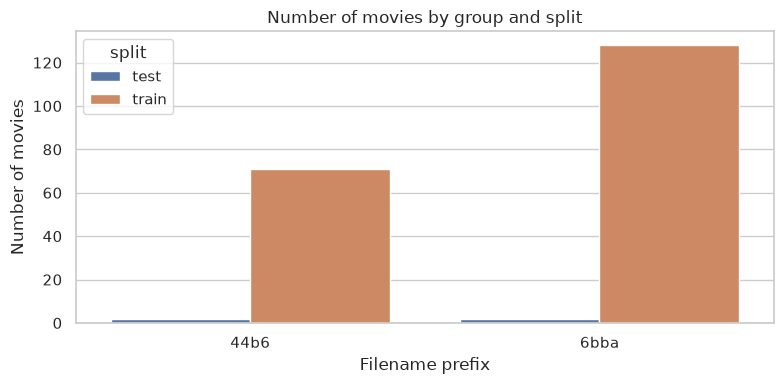

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 4))

ax = sns.barplot(
    data=group_counts,
    x="group",
    y="n_movies",
    hue="split"
)

ax.set(
    title="Number of movies by group and split",
    xlabel="Filename prefix",
    ylabel="Number of movies"
)

plt.tight_layout()
plt.show()

### Apparent dataset groups

The movie identifiers begin with either `44b6` or `6bba`:

- `44b6`: 71 training movies and 2 test movies
- `6bba`: 128 training movies and 2 test movies

At this stage, these prefixes are treated as dataset groups. Their biological or experimental meaning has not yet been confirmed.

The training data are imbalanced across the two groups, with approximately 129/199 * 100 = 64.3% of the movies belonging to `6bba`. This may matter if the groups differ in image characteristics, cell density, movement patterns or annotation structure.

A validation strategy should eventually measure performance within each group rather than relying only on one pooled score.

## Inspect Submission Structure

In [6]:
sample_submission = pd.read_csv(
    DATA_ROOT / "sample_submission.csv"
)

print("Shape:", sample_submission.shape)
print("\nColumns:")
print(sample_submission.columns.tolist())

print("\nFirst 10 rows:")
display(sample_submission.head(10))

print("\nDataset values:")
print(sample_submission["dataset"].value_counts(dropna=False))

print("\nRow types:")
print(sample_submission["row_type"].value_counts(dropna=False))

Shape: (20, 10)

Columns:
['id', 'dataset', 'row_type', 'node_id', 't', 'z', 'y', 'x', 'source_id', 'target_id']

First 10 rows:


,id,dataset,row_type,node_id,t,z,y,x,source_id,target_id
0,0,44b6_0113de3b,node,1,0,32,128,128,-1,-1
1,1,44b6_0113de3b,node,2,1,32,128,128,-1,-1
2,2,44b6_0113de3b,node,3,2,32,128,128,-1,-1
3,3,44b6_0113de3b,edge,-1,-1,-1,-1,-1,1,2
4,4,44b6_0113de3b,edge,-1,-1,-1,-1,-1,2,3
5,5,44b6_0b24845f,node,1,0,32,128,128,-1,-1
6,6,44b6_0b24845f,node,2,1,32,128,128,-1,-1
7,7,44b6_0b24845f,node,3,2,32,128,128,-1,-1
8,8,44b6_0b24845f,edge,-1,-1,-1,-1,-1,1,2
9,9,44b6_0b24845f,edge,-1,-1,-1,-1,-1,2,3



Dataset values:
dataset
44b6_0113de3b    5
44b6_0b24845f    5
6bba_05b6850b    5
6bba_05db0fb1    5
Name: count, dtype: int64

Row types:
row_type
node    12
edge     8
Name: count, dtype: int64


In [7]:
display(
    sample_submission.groupby(["dataset", "row_type"])
    .size()
    .rename("n_rows")
    .reset_index()
)

,dataset,row_type,n_rows
0,44b6_0113de3b,edge,2
1,44b6_0113de3b,node,3
2,44b6_0b24845f,edge,2
3,44b6_0b24845f,node,3
4,6bba_05b6850b,edge,2
5,6bba_05b6850b,node,3
6,6bba_05db0fb1,edge,2
7,6bba_05db0fb1,node,3


### Submission structure

The sample submission contains two row types:

- `node`: a predicted cell detection with a node ID, timepoint and 3D voxel coordinates
- `edge`: a directed link from a source node to a target node

The example contains three nodes and two edges for each test movie. These are placeholder predictions that demonstrate the required format, not expected cell counts.

Each of the four test movies must appear in the final submission. Node IDs only need to identify nodes within their corresponding dataset, while the `id` column must be a consecutive global row index.

## Inspect One Zarr Movie

In [ ]:
import zarr
import numpy as np

# sample_id = "44b6_0113de3b"
sample_id = "6bba_afb141ff"

train_zarr_path = train_root / f"{sample_id}.zarr"
test_zarr_path = test_root / f"{sample_id}.zarr"
geff_path = train_root / f"{sample_id}.geff"

print("Zarr version:", zarr.__version__)
print("Training path:", train_zarr_path)
print("Test path:", test_zarr_path)
print("GEFF path:", geff_path)

Zarr version: 3.2.1
Training path: /home/priyam-ambastha/Desktop/biohub-cell-tracking-during-development/train/44b6_0113de3b.zarr
Test path: /home/priyam-ambastha/Desktop/biohub-cell-tracking-during-development/test/44b6_0113de3b.zarr
GEFF path: /home/priyam-ambastha/Desktop/biohub-cell-tracking-during-development/train/44b6_0113de3b.geff


In [9]:
train_store = zarr.open(str(train_zarr_path), mode="r")

print("Object type:", type(train_store))
print(train_store)

Object type: <class 'zarr.core.group.Group'>
<Group file:///home/priyam-ambastha/Desktop/biohub-cell-tracking-during-development/train/44b6_0113de3b.zarr>


In [10]:
if hasattr(train_store, "tree"):
    print(train_store.tree())
else:
    print("This object has no tree method.")

/
└── 0 (100, 64, 256, 256) uint16



In [11]:
arr = train_store["0"]

print(type(arr))
print(arr.shape)

<class 'zarr.core.array.Array'>
(100, 64, 256, 256)


In [12]:
import napari

viewer = napari.Viewer()
viewer.add_image(arr)
napari.run()


(python:756603): dbind-WARNING **: 21:07:12.353: Couldn't connect to accessibility bus: Failed to connect to socket /root/.cache/at-spi/bus_1: Permission denied


In [18]:
if hasattr(train_store, "attrs"):
    print("Root attributes:")
    
    for key, value in train_store.attrs.items():
        print(f"{key}: {value}")

Root attributes:
multiscales: [{'version': '0.5', 'axes': [{'name': 'T', 'type': 'time', 'unit': 'second'}, {'name': 'Z', 'type': 'space', 'unit': 'micrometer'}, {'name': 'Y', 'type': 'space', 'unit': 'micrometer'}, {'name': 'X', 'type': 'space', 'unit': 'micrometer'}], 'datasets': [{'path': '0', 'coordinateTransformations': [{'type': 'scale', 'scale': [1.0, 1.625, 0.40625, 0.40625]}]}], 'name': '0'}]
image_statistics: {'quantiles': {'0.0': 15.0, '0.001': 26.222222222222225, '0.01': 38.0, '0.1': 75.0, '0.9': 497.0, '0.99': 1478.0, '0.999': 2145.000000039654, '1.0': 4319.0}}


### Structure of an example microscopy movie

The movie `44b6_0113de3b` contains one four-dimensional image array with shape `(100, 64, 256, 256)`. According to the metadata, the dimensions represent time, depth, height and width: `(T, Z, Y, X)`.

The movie therefore contains 100 timepoints, with each timepoint represented by 64 images of size 256 × 256. Intensities are stored as unsigned 16-bit integers.

The physical spacing is:

- 1 second per timepoint
- 1.625 µm per voxel along the Z-axis
- 0.40625 µm per voxel along the Y- and X-axes

64 * 1.625=104 μm  
256 * 0.40625 =104 μm  
This gives an approximately cubic physical field of view of 104 × 104 × 104 µm. However, the individual voxels are anisotropic: one Z step covers four times the physical distance of one X or Y step (1.625/0.40626 = 4). Spatial distances must therefore be calculated using physical coordinates rather than unscaled voxel coordinates.

The array contains approximately 419 million intensity values and would occupy about 800 MiB if loaded uncompressed. Zarr's chunked storage allows selected frames and slices to be read without loading the complete movie.

The supplied intensity quantiles indicate a strongly right-skewed distribution. Most voxels have relatively low intensities, while a small proportion are substantially brighter. Visual inspection is required before interpreting the bright regions as cellular structures.

## Compare Train and Test Versions

In [19]:
test_store = zarr.open(str(test_zarr_path), mode="r")

print("Training store:")
print(train_store)

print("\nTest store:")
print(test_store)

print("\nTraining hierarchy:")
if hasattr(train_store, "tree"):
    print(train_store.tree())

print("\nTest hierarchy:")
if hasattr(test_store, "tree"):
    print(test_store.tree())

Training store:
<Group file:///home/priyam-ambastha/Desktop/biohub-cell-tracking-during-development/train/44b6_0113de3b.zarr>

Test store:
<Group file:///home/priyam-ambastha/Desktop/biohub-cell-tracking-during-development/test/44b6_0113de3b.zarr>

Training hierarchy:
/
└── 0 (100, 64, 256, 256) uint16


Test hierarchy:
/
└── 0 (100, 64, 256, 256) uint16



In [20]:
train_attrs = dict(train_store.attrs)
test_attrs = dict(test_store.attrs)

print("Same root attributes:", train_attrs == test_attrs)

print("\nTraining attributes:")
print(train_attrs)

print("\nTest attributes:")
print(test_attrs)

Same root attributes: True

Training attributes:
{'multiscales': [{'version': '0.5', 'axes': [{'name': 'T', 'type': 'time', 'unit': 'second'}, {'name': 'Z', 'type': 'space', 'unit': 'micrometer'}, {'name': 'Y', 'type': 'space', 'unit': 'micrometer'}, {'name': 'X', 'type': 'space', 'unit': 'micrometer'}], 'datasets': [{'path': '0', 'coordinateTransformations': [{'type': 'scale', 'scale': [1.0, 1.625, 0.40625, 0.40625]}]}], 'name': '0'}], 'image_statistics': {'quantiles': {'0.0': 15.0, '0.001': 26.222222222222225, '0.01': 38.0, '0.1': 75.0, '0.9': 497.0, '0.99': 1478.0, '0.999': 2145.000000039654, '1.0': 4319.0}}}

Test attributes:
{'multiscales': [{'version': '0.5', 'axes': [{'name': 'T', 'type': 'time', 'unit': 'second'}, {'name': 'Z', 'type': 'space', 'unit': 'micrometer'}, {'name': 'Y', 'type': 'space', 'unit': 'micrometer'}, {'name': 'X', 'type': 'space', 'unit': 'micrometer'}], 'datasets': [{'path': '0', 'coordinateTransformations': [{'type': 'scale', 'scale': [1.0, 1.625, 0.40625,

### Comparison of the train and test versions

The train and test versions of `44b6_0113de3b` have identical array hierarchies, shapes, data types, physical scales and stored intensity statistics.

This provides strong evidence that they represent the same underlying microscopy movie. The competition's test set therefore appears to select four movies from the training collection rather than introducing four entirely new image sequences.

Metadata equality does not by itself prove that every pixel is identical. A sample of image slices will be compared later to verify the image content.

## Inspect the GEFF hierarchy

In [14]:
geff_store = zarr.open(str(geff_path), mode="r")

print("GEFF object type:", type(geff_store))
print(geff_store)

if hasattr(geff_store, "tree"):
    print("\nGEFF hierarchy:")
    print(geff_store.tree())

print("\nGEFF root attributes:")
for key, value in geff_store.attrs.items():
    print(f"{key}: {value}")

GEFF object type: <class 'zarr.core.group.Group'>
<Group file:///home/priyam-ambastha/Desktop/biohub-cell-tracking-during-development/train/44b6_0113de3b.geff>

GEFF hierarchy:
/
├── edges
│   ├── ids (50, 2) uint64
│   └── props
└── nodes
    ├── ids (52,) uint64
    └── props
        ├── t
        │   └── values (52,) int64
        ├── x
        │   └── values (52,) int64
        ├── y
        │   └── values (52,) int64
        └── z
            └── values (52,) int64


GEFF root attributes:
geff: {'geff_version': '1.1', 'directed': True, 'axes': [{'name': 't', 'type': 'time', 'unit': None, 'min': 0.0, 'max': 75.0, 'scale': 1.0, 'scaled_unit': None, 'offset': None}, {'name': 'z', 'type': 'space', 'unit': None, 'min': 1.0, 'max': 63.0, 'scale': 1.625, 'scaled_unit': None, 'offset': None}, {'name': 'y', 'type': 'space', 'unit': None, 'min': 74.0, 'max': 230.0, 'scale': 0.40625, 'scaled_unit': None, 'offset': None}, {'name': 'x', 'type': 'space', 'unit': None, 'min': 73.0, 'max': 253.0,

In [15]:
import numpy as np

nodes = geff_store["nodes"]

t = np.asarray(nodes["props"]["t"]["values"])
z = np.asarray(nodes["props"]["z"]["values"])
y = np.asarray(nodes["props"]["y"]["values"])
x = np.asarray(nodes["props"]["x"]["values"])

coords = np.column_stack((t, z, y, x))

In [20]:
import numpy as np

t = np.asarray(geff_store["nodes"]["props"]["t"]["values"])

unique_t, counts = np.unique(t, return_counts=True)

for tt, c in zip(unique_t, counts):
    print(f"t={tt:2d}: {c} nodes")

t= 0: 1 nodes
t= 1: 1 nodes
t= 2: 1 nodes
t=27: 1 nodes
t=28: 1 nodes
t=29: 1 nodes
t=30: 1 nodes
t=31: 1 nodes
t=32: 1 nodes
t=33: 1 nodes
t=34: 1 nodes
t=35: 1 nodes
t=36: 1 nodes
t=37: 1 nodes
t=38: 1 nodes
t=39: 1 nodes
t=40: 1 nodes
t=41: 1 nodes
t=42: 1 nodes
t=43: 1 nodes
t=44: 1 nodes
t=45: 1 nodes
t=46: 1 nodes
t=47: 1 nodes
t=48: 1 nodes
t=49: 1 nodes
t=50: 1 nodes
t=51: 1 nodes
t=52: 1 nodes
t=53: 1 nodes
t=54: 1 nodes
t=55: 1 nodes
t=56: 1 nodes
t=57: 1 nodes
t=58: 1 nodes
t=59: 1 nodes
t=60: 1 nodes
t=61: 1 nodes
t=62: 1 nodes
t=63: 1 nodes
t=64: 1 nodes
t=65: 1 nodes
t=66: 1 nodes
t=67: 1 nodes
t=68: 1 nodes
t=69: 1 nodes
t=70: 1 nodes
t=71: 1 nodes
t=72: 1 nodes
t=73: 1 nodes
t=74: 1 nodes
t=75: 1 nodes


In [17]:
viewer.add_points(
    coords,
    size=5,
    face_color="red",
    # edge_color="white",
    name="cells",
)

<Points layer 'cells' at 0x7e88f4dbfe00>

### Sparse GEFF lineage annotations

The GEFF file for `44b6_0113de3b` contains 52 annotated nodes and 50 directed edges. Each node has an integer timepoint and `(z, y, x)` centroid coordinates in voxel units. Each edge stores a source and target node ID and represents a directed temporal or lineage connection (order matters: an edge u→v means the cell represented by u is connected forward in time to v).

The annotations cover timepoints 0–75, although the microscopy movie contains timepoints 0–99. The spatial coordinate ranges describe the locations of annotated nodes and should not be confused with the complete image dimensions.

The graph metadata estimates that the complete movie contains approximately 25,755 cell nodes across time. The 52 supplied nodes represent only about 0.2% of that estimate, providing clear evidence that the training graph is extremely sparsely annotated.

Consequently, an unannotated cell-like object cannot be assumed to be a negative example. The supplied graph provides examples of true cells and true lineage connections, but it does not provide an exhaustive record of every cell.

In [22]:
node_ids = geff_store["nodes/ids"][:]

nodes = pd.DataFrame({
    "node_id": node_ids,
    "t": geff_store["nodes/props/t/values"][:],
    "z": geff_store["nodes/props/z/values"][:],
    "y": geff_store["nodes/props/y/values"][:],
    "x": geff_store["nodes/props/x/values"][:]
})

edge_ids = geff_store["edges/ids"][:]

edges = pd.DataFrame({
    "source_id": edge_ids[:, 0],
    "target_id": edge_ids[:, 1]
})

print("Nodes shape:", nodes.shape)
display(nodes.head(10))

print("Edges shape:", edges.shape)
display(edges.head(10))

Nodes shape: (52, 5)


,node_id,t,z,y,x
0,11000000075,0,63,222,249
1,12000000075,1,63,227,251
2,13000000075,2,63,230,253
3,38000000003,27,1,74,73
4,39000000003,28,3,78,75
5,40000000003,29,5,80,77
6,41000000003,30,7,86,78
7,42000000003,31,9,91,77
8,43000000003,32,11,98,81
9,44000000003,33,11,104,78


Edges shape: (50, 2)


,source_id,target_id
0,11000000075,12000000075
1,12000000075,13000000075
2,38000000003,39000000003
3,39000000003,40000000003
4,40000000003,41000000003
5,41000000003,42000000003
6,42000000003,43000000003
7,43000000003,44000000003
8,44000000003,45000000003
9,45000000003,46000000003


In [23]:
print("Duplicate node IDs:", nodes["node_id"].duplicated().sum())
print("Missing node values:", nodes.isna().sum().sum())
print("Duplicate edges:", edges.duplicated().sum())

known_node_ids = set(nodes["node_id"])

unknown_sources = set(edges["source_id"]) - known_node_ids
unknown_targets = set(edges["target_id"]) - known_node_ids

print("Unknown source IDs:", unknown_sources)
print("Unknown target IDs:", unknown_targets)

Duplicate node IDs: 0
Missing node values: 0
Duplicate edges: 0
Unknown source IDs: set()
Unknown target IDs: set()


### Graph extraction and integrity checks

The example GEFF graph was converted into two tabular structures:

- a node table containing the node ID, timepoint and voxel coordinates;
- an edge table containing directed source–target node pairs.

The graph passes the initial integrity checks. Node IDs are unique, node attributes contain no missing values, edges are unique, and every edge endpoint refers to a node contained in the graph.

The large numerical node IDs are treated only as identifiers. No biological or temporal interpretation is inferred from their numerical values because time and position are stored explicitly as node attributes.

In [24]:
import networkx as nx

G = nx.DiGraph()

for row in nodes.itertuples(index=False):
    G.add_node(
        int(row.node_id),
        t=int(row.t),
        z=int(row.z),
        y=int(row.y),
        x=int(row.x)
    )

G.add_edges_from(
    (int(row.source_id), int(row.target_id))
    for row in edges.itertuples(index=False)
)

print("Number of vertices:", G.number_of_nodes())
print("Number of directed edges:", G.number_of_edges())
print("Directed acyclic graph:", nx.is_directed_acyclic_graph(G))
print("Number of self-loops:", nx.number_of_selfloops(G))

weak_components = list(nx.weakly_connected_components(G))
strong_components = list(nx.strongly_connected_components(G))

print("Weakly connected components:", len(weak_components))
print("Strongly connected components:", len(strong_components))

print(
    "Weak component sizes:",
    sorted([len(component) for component in weak_components], reverse=True)
)

Number of vertices: 52
Number of directed edges: 50
Directed acyclic graph: True
Number of self-loops: 0
Weakly connected components: 2
Strongly connected components: 52
Weak component sizes: [49, 3]


In [25]:
degree_summary = pd.DataFrame({
    "node_id": list(G.nodes),
    "in_degree": [G.in_degree(node) for node in G.nodes],
    "out_degree": [G.out_degree(node) for node in G.nodes]
})

degree_summary = degree_summary.merge(
    nodes,
    on="node_id",
    how="left"
)

print("In-degree counts:")
display(
    degree_summary["in_degree"]
    .value_counts()
    .sort_index()
    .rename_axis("in_degree")
    .reset_index(name="n_nodes")
)

print("Out-degree counts:")
display(
    degree_summary["out_degree"]
    .value_counts()
    .sort_index()
    .rename_axis("out_degree")
    .reset_index(name="n_nodes")
)

In-degree counts:


,in_degree,n_nodes
0,0,2
1,1,50


Out-degree counts:


,out_degree,n_nodes
0,0,2
1,1,50


In [26]:
root_nodes = degree_summary[
    degree_summary["in_degree"] == 0
]

leaf_nodes = degree_summary[
    degree_summary["out_degree"] == 0
]

division_nodes = degree_summary[
    degree_summary["out_degree"] >= 2
]

merge_nodes = degree_summary[
    degree_summary["in_degree"] >= 2
]

print("Root nodes:", len(root_nodes))
print("Leaf nodes:", len(leaf_nodes))
print("Division nodes:", len(division_nodes))
print("Merge nodes:", len(merge_nodes))

print("\nDivision-node details:")
display(division_nodes.sort_values("t"))

print("\nMerge-node details:")
display(merge_nodes.sort_values("t"))

Root nodes: 2
Leaf nodes: 2
Division nodes: 0
Merge nodes: 0

Division-node details:


,node_id,in_degree,out_degree,t,z,y,x



Merge-node details:


,node_id,in_degree,out_degree,t,z,y,x


### Graph topology of the example annotation

The annotation graph is a directed acyclic graph containing two weakly connected components of sizes 49 and 3. Every non-root vertex has in-degree 1, and every non-leaf vertex has out-degree 1.

Consequently, the graph is the disjoint union of two directed paths:

$$P_{49} \sqcup P_3$$

The expected number of edges is therefore:

$$(49-1)+(3-1)=50,$$

which agrees with the observed edge count.

The graph contains no annotated divisions, merges, self-loops or cycles. This describes the supplied sparse annotation only; it does not demonstrate that the complete microscopy movie contains no cell divisions.

Roots and leaves represent the beginning and end of observed annotations rather than necessarily representing biological births and disappearances.
